In [2]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
#import torch_directml
import torch.nn as nn

import torch.nn as nn

class MelDiscriminator(nn.Module):
    """Discriminator for (1, 64, 512) mel spectrograms."""
    def __init__(self, features_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            # (1, 64, 512) → (features_dim, 32, 256)
            nn.Conv2d(1, features_dim, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # → (features_dim*2, 16, 128)
            nn.Conv2d(features_dim, features_dim*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_dim*2),
            nn.LeakyReLU(0.2, inplace=True),
            # → (features_dim*4, 8, 64)
            nn.Conv2d(features_dim*2, features_dim*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_dim*4),
            nn.LeakyReLU(0.2, inplace=True),
            # → (features_dim*8, 4, 32)
            nn.Conv2d(features_dim*4, features_dim*8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_dim*8),
            nn.LeakyReLU(0.2, inplace=True),
            # → (features_dim*16, 2, 16)
            nn.Conv2d(features_dim*8, features_dim*16, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_dim*16),
            nn.LeakyReLU(0.2, inplace=True),
            # → (1, 1, 1) — final real/fake score
            nn.Conv2d(features_dim*16, 1, kernel_size=(2, 16), stride=1, padding=0, bias=False),
        )

    def forward(self, x):
        return self.net(x)


class MelGenerator(nn.Module):
    """Generator producing (1, 64, 512) mel spectrograms from latent vector."""
    def __init__(self, latent_dim=100, features_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            # Input: (latent_dim, 1, 1)
            # → (features_dim*16, 2, 16)
            nn.ConvTranspose2d(latent_dim, features_dim*16, kernel_size=(2, 16), stride=1, padding=0, bias=False),
            nn.BatchNorm2d(features_dim*16),
            nn.ReLU(True),
            # → (features_dim*8, 4, 32)
            nn.ConvTranspose2d(features_dim*16, features_dim*8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_dim*8),
            nn.ReLU(True),
            # → (features_dim*4, 8, 64)
            nn.ConvTranspose2d(features_dim*8, features_dim*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_dim*4),
            nn.ReLU(True),
            # → (features_dim*2, 16, 128)
            nn.ConvTranspose2d(features_dim*4, features_dim*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_dim*2),
            nn.ReLU(True),
            # → (features_dim, 32, 256)
            nn.ConvTranspose2d(features_dim*2, features_dim, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_dim),
            nn.ReLU(True),
            # → (1, 64, 512)
            nn.ConvTranspose2d(features_dim, 1, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)
    
class MelChunkDataset(Dataset):
    def __init__(self, npy_path):
        data = np.load(npy_path)
        self.data = torch.from_numpy(data)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        chunk = self.data[idx]                          # (1, 64, 431)
        chunk = torch.nn.functional.pad(chunk, (0, 81)) # pad to (1, 64, 512)
        return chunk
      

dataset = MelChunkDataset("mel_electronic_dataset.npy")
loader = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=0, pin_memory=True)

print(f"Dataset size: {len(dataset)} chunks")
print(f"Batch shape: {next(iter(loader)).shape}")  # should be (128, 1, 64, 256)

Dataset size: 9990 chunks
Batch shape: torch.Size([128, 1, 64, 512])


## Defining the Generator and Discriminator

Determine the device to be used in the computations ...

In [3]:
def get_device():
    """Select device where to perform the computations."""
    #if torch_directml.is_available():
    #    return torch_directml.device()
    if torch.cuda.is_available():
        return torch.device("cuda:0")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")

device = get_device()

print(f"Selected device: {device}")

Selected device: cuda:0


... instantiate the generator ...

In [4]:
import deeplay as dl

latent_dim = 100
features_dim = 64

gen = MelGenerator(latent_dim=latent_dim, features_dim=features_dim).to(device)

... and instantiate the discriminator.

In [5]:
disc = MelDiscriminator(features_dim=features_dim).to(device)

## Training the GAN

Define the data loader ...

... define the loss function ...

In [6]:
criterion = nn.BCEWithLogitsLoss()

... define the optimizers ...

In [7]:
optim_gen = torch.optim.Adam(gen.parameters(), lr=0.0002, betas=(0.5, 0.999))
optim_disc = torch.optim.Adam(disc.parameters(), lr=0.0002, betas=(0.5, 0.999))

... implement the adversarial training ...

In [ ]:
import time
from datetime import timedelta

epochs = 150
batch_size = 128
num_batches = len(loader)
gen_losses_avg, disc_losses_avg = [], []
fix_latent_vector = torch.randn(30, latent_dim, 1, 1).to(device)
for epoch in range(epochs):
    gen.train(), disc.train()

    print("\n" + f"Epoch {epoch + 1 }/{epochs}" + "\n" + "-" * 10)
    start_time = time.time()

    running_gen_loss, running_disc_loss = 0.0, 0.0
    for batch_idx, real_images in enumerate(loader):
        real_images = real_images.to(device)
        B = real_images.size(0)  

        noise = torch.randn(B, latent_dim, 1, 1).to(device)
        fake_images = gen(noise)

        # 1. Discriminator training
        real_output = disc(real_images).reshape(-1)
        fake_output = disc(fake_images.detach()).reshape(-1)  # detach here

        real_loss = criterion(real_output, torch.full_like(real_output, 0.9))  # label smoothing
        fake_loss = criterion(fake_output, torch.zeros_like(fake_output))
        disc_loss = (real_loss + fake_loss) / 2

        optim_disc.zero_grad()
        disc_loss.backward()  # no retain_graph needed anymore
        optim_disc.step()

        # do we add generator training (3x per disc step)
        #for _ in range(1):
        noise = torch.randn(B, latent_dim, 1, 1).to(device)
        fake_images = gen(noise)
        fake_output = disc(fake_images).reshape(-1)
        gen_loss = criterion(fake_output, torch.ones_like(fake_output))
        optim_gen.zero_grad()
        gen_loss.backward()
        optim_gen.step()
        
        running_gen_loss += gen_loss.item()
        running_disc_loss += disc_loss.item()


        if torch.isnan(gen_loss) or torch.isnan(disc_loss):
            print(f"NaN detected at batch {batch_idx}! Stopping.")
            break


    gen_losses_avg.append(running_gen_loss / num_batches)
    disc_losses_avg.append(running_disc_loss / num_batches)
    end_time = time.time()

    print("-" * 10 + "\n" + f"Epoch {epoch + 1}/{epochs}: "
          f"Generator Loss: {gen_losses_avg[-1]:.4f}, "
          f"Discriminator Loss: {disc_losses_avg[-1]:.4f}, "
          f"Time taken: {timedelta(seconds=end_time - start_time)}")
    torch.save({'epoch' : epoch + 1,
                'gen_state_dict' :gen.state_dict(),
                'gen_losses' : gen_losses_avg,
                'disc_losses' : disc_losses_avg,
    }, f"gan_checkpoint_epoch{epoch+1}.pt")
    '''
    gen.eval(), disc.eval()
    fake_images = gen(fix_latent_vector).detach().cpu().numpy()

    fig, axs = plt.subplots(3, 10, figsize=(20, 6))
    for i, ax in enumerate(axs.ravel()):
        ax.imshow(fake_images[i][0], cmap="gray")
        ax.axis("off")
    plt.tight_layout()
    plt.show()
    plt.close(fig)
    '''


Epoch 1/2
----------
----------
Epoch 1/2: Generator Loss: 0.0000, Discriminator Loss: 0.0000, Time taken: 0:00:48.995308

Epoch 2/2
----------
----------
Epoch 2/2: Generator Loss: 0.0000, Discriminator Loss: 0.0000, Time taken: 0:00:50.039680


In [9]:
# Check data isn't all zeros/nans
batch = next(iter(loader))
print(batch.min(), batch.max(), torch.isnan(batch).any())

# ceck model outputs not collapsing
noise = torch.randn(4, latent_dim, 1, 1).to(device)
with torch.no_grad():
    fake = gen(noise)
    score = disc(fake)
print(fake.min(), fake.max())
print(score.min(), score.max())

tensor(-1.) tensor(1.) tensor(False)
tensor(-1., device='cuda:0') tensor(1., device='cuda:0')
tensor(1.0293, device='cuda:0') tensor(3.0739, device='cuda:0')


## Plotting the Training Losses

In [10]:
SR = 22050           # sample rate
N_FFT = 1024         # FFT window size
HOP_LENGTH = 256     # hop length
N_MELS = 64          # mel frequency bins


def mel_chunk_to_audio(chunk, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH):
    """Convert a single (1, n_mels, chunk_frames) chunk back to audio"""
    mel_norm = chunk.squeeze()             # (n_mels, chunk_frames)
    mel_db = mel_norm * 40 - 40            # denormalize
    mel_power = librosa.db_to_power(mel_db)
    audio = librosa.feature.inverse.mel_to_audio(mel_power, sr=sr,
                                                  n_fft=n_fft,
                                                  hop_length=hop_length)
    return audio

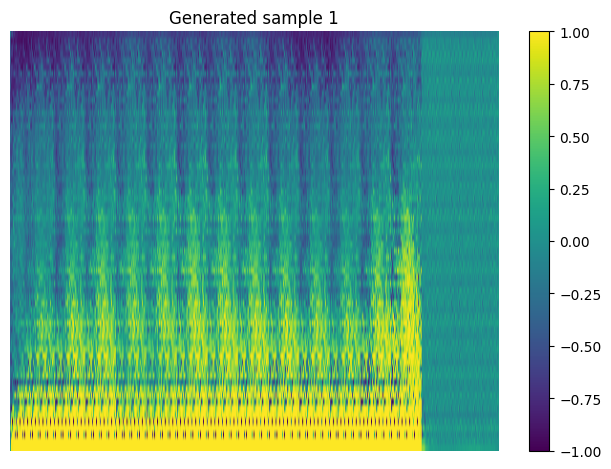

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
import librosa

gen.eval()
fake_images = gen(fix_latent_vector).detach().cpu().numpy()

#for i in range(3):
audio = mel_chunk_to_audio(fake_images[0])
    
plt.imshow(fake_images[0][0], origin="lower", aspect="auto")
plt.axis("off")
plt.title(f"Generated sample {0+1}")
plt.colorbar()
plt.tight_layout()
plt.show()    
ipd.display(ipd.Audio(audio, rate=SR))

In [ ]:
# Make sure this points to your NEW checkpoint, not the old one
checkpoint = torch.load("gan_checkpoint_epoch2.pt", map_location="cpu")
print(checkpoint["gen_losses"])   # should show ~5 values around 0.6-1.5
print(checkpoint["disc_losses"])  # should show ~5 values around 0.6-1.0

[0.0, 0.0]
[0.0, 0.0]


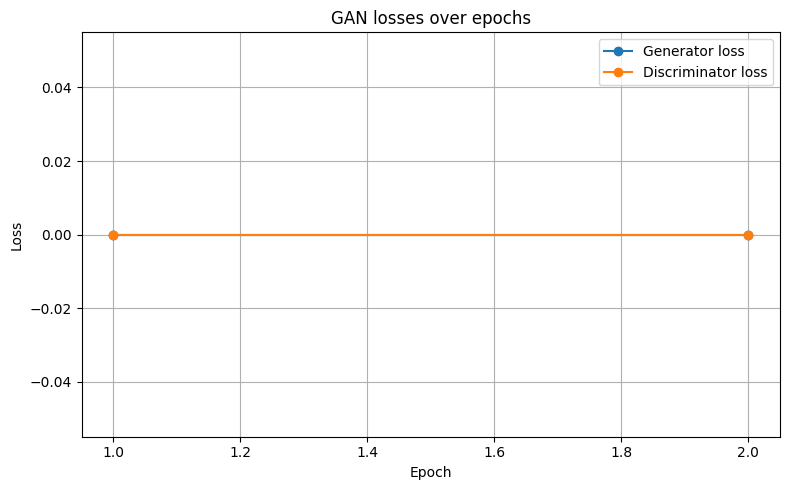

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(gen_losses_avg) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, gen_losses_avg, label="Generator loss", marker="o")
plt.plot(epochs, disc_losses_avg, label="Discriminator loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN losses over epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()